In [68]:
import os
import re
import numpy as np
import tifffile
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
from natsort import natsorted
import pandas as pd
import glob

import matplotlib.patches as mpatches
import matplotlib.path as mpath 
from matplotlib.collections import PathCollection
import matplotlib.colors as mcolors


import cv2
from PIL import Image, ImageSequence
import av
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.gridspec as gridspec


In [6]:
# Function to sort files naturally
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

# Function to calculate SSIM
def calculate_ssim(original_file, compressed_file):
    ssim_scores = []
    with tifffile.TiffFile(original_file) as tif_original:
        with tifffile.TiffFile(compressed_file) as tif_compressed:
            for original_frame, compressed_frame in zip(tif_original.series[0].pages, tif_compressed.series[0].pages):
                original_image = original_frame.asarray()
                compressed_image = compressed_frame.asarray()
                score = ssim(original_image, compressed_image, data_range=compressed_image.max() - compressed_image.min())
                ssim_scores.append(score)
    return np.median(ssim_scores) 

# New function to calculate SSIM
def calculate_ssim_folder(original_folder, compressed_folder):
    ssim_results = []
    original_files = natsorted([f for f in os.listdir(original_folder) if f.endswith('.tiff') and not f.startswith('.')])
    compressed_files = natsorted([f for f in os.listdir(compressed_folder) if f.endswith('.tiff') and not f.startswith('.')])
    
    for original_file, compressed_file in zip(original_files, compressed_files):
        ssim_scores = []
        try:
            with tifffile.TiffFile(os.path.join(original_folder, original_file)) as tif_original:
                with tifffile.TiffFile(os.path.join(compressed_folder, compressed_file)) as tif_compressed:
                    for original_frame, compressed_frame in zip(tif_original.series[0].pages, tif_compressed.series[0].pages):
                        original_image = original_frame.asarray()
                        compressed_image = compressed_frame.asarray()
                        score = ssim(original_image, compressed_image, data_range=compressed_image.max() - compressed_image.min())
                        ssim_scores.append(score)
            if ssim_scores:
                median_ssim = np.median(ssim_scores)
                ssim_results.append({'original_file': original_file, 'compressed_file': compressed_file, 'ssim': median_ssim})
        except Exception as e:
            print(f"Error processing files {original_file} and {compressed_file}: {e}")
    return ssim_results


# Function to get the total size of files in a folder
def get_total_size_of_files(folder_path, file_extensions):
    total_size = 0
    for file in os.listdir(folder_path):
        if any(file.endswith(ext) for ext in file_extensions):
            total_size += os.path.getsize(os.path.join(folder_path, file))
    return total_size

# Function to extract the k and lev values from the label
def extract_k_lev(label):
    """
    Extracts the k and lev values from the label.
    Assumes the label format is like 'sparz_k5_rt35_lev0'.
    """
    k_match = re.search(r'_k(\d+)_', label)
    lev_match = re.search(r'_lev(\d+)', label)
    k_value = int(k_match.group(1)) if k_match else None
    lev_value = int(lev_match.group(1)) if lev_match else None
    return k_value, lev_value

# Astigmatism data

In [ ]:

# Change these paths according to your directory structure
main_folder = '/Users/laurabreimann/Desktop/astigmatism'
original_file = '/Users/laurabreimann/Desktop/astigmatism_raw/sequence-as-stack-MT0.N1.HD-AS-Exp.tif'

In [ ]:

# Original file size
original_file_size = 20822904   # in bytes


# Color map for kernel sizes
k_colors = plt.cm.viridis(np.linspace(0, 1, 4))
lev_shades = np.linspace(0.5, 1, 4)
k_values = [5,7,9,11]

# Marker map for threshold values
threshold_markers = {35: 'o', 45: '^', 55: 's', 65: 'd'}

# Iterate through each subfolder and calculate median SSIM score and file size
results = {}
for folder in sorted(os.listdir(main_folder), key=natural_sort_key):
    if os.path.isdir(os.path.join(main_folder, folder)):
        uncompressed_folder = os.path.join(main_folder, folder, 'uncompressed')
        # Handling different file endings by searching for the common beginning
        for file_name in os.listdir(uncompressed_folder):
            if file_name.startswith('MT0_sequence-as-stack-MT0.N1'):
                compressed_file = os.path.join(uncompressed_folder, file_name)
                break
        median_ssim = calculate_ssim(original_file, compressed_file)
        total_file_size = get_total_size_of_files(os.path.join(main_folder, folder), ['.mp4', '.npz'])  
        file_size_percentage = (total_file_size / original_file_size) * 100
        k_value, lev_value = extract_k_lev(folder)
        threshold = int(re.search(r'rt(\d+)', folder).group(1))  # Extract threshold value

        # Choose marker based on threshold value
        marker = threshold_markers[threshold]

        color = k_colors[k_values.index(k_value)]

        # Choose shade based on lev value
        shade = lev_shades[lev_value] if lev_value is not None else 0.5

        if lev_value not in results:
            results[lev_value] = []
        results[lev_value].append({'median_ssim': median_ssim, 'file_size_percentage': file_size_percentage, 'color': color, 'shade': shade, 'marker': marker })



In [ ]:
# Create facet plot
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for i, (level, data_list) in enumerate(sorted(results.items())):
    ax = axs[i]
    ax.set_xlabel('Percentage of Original File Size')
    ax.set_title(f'Compression Level {level}')
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.2, zorder=0)
    for data in data_list:
        ax.scatter(data['file_size_percentage'], data['median_ssim'], color=data['color'],s=250, marker=data['marker'], alpha=0.9)
    ax.set_xlim(0, 50)

# Remove lines on top and right
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Set common Y axis label
fig.text(0, 0.55, 'Median SSIM Score', va='center', rotation='vertical')

plt.tight_layout()
#plt.show()

# Save the plot as a PDF
output_file = '/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/Figure_3_SSIM_filesize_240422.pdf'
plt.tight_layout()
plt.savefig(output_file, format='pdf')
plt.close()

### Make astigmatism cartoon

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def elliptical_gaussian(x, y, sigma_x, sigma_y):
    """
    Generate a 2D elliptical Gaussian function.
    
    Parameters:
    - x: x coordinates
    - y: y coordinates
    - sigma_x: standard deviation in x direction
    - sigma_y: standard deviation in y direction
    
    Returns:
    - 2D elliptical Gaussian function values.
    """
    return np.exp(-((x / sigma_x)**2 + (y / sigma_y)**2) / 2)

def generate_astigmatic_psf(image_size, dxy, dz, sigma_0x, sigma_0y, Ax, Ay, Bx, By, z_positions):
    """
    Generate a series of 2D Gaussian point spread functions (PSF) with astigmatism at different z-positions.
    
    Parameters:
    - image_size: tuple of (height, width) of the output image.
    - dxy: pixel size in xy-plane in microns.
    - dz: pixel size in z-direction in microns.
    - sigma_0x: base standard deviation in x direction.
    - sigma_0y: base standard deviation in y direction.
    - Ax, Ay: astigmatism coefficients.
    - Bx, By: higher-order astigmatism coefficients.
    - z_positions: list of z positions for which to generate the PSFs.
    
    Returns:
    - psfs: list of 2D arrays representing the PSFs at different z-positions.
    """
    y = np.linspace(-image_size[0]//2, image_size[0]//2, image_size[0]) * dxy
    x = np.linspace(-image_size[1]//2, image_size[1]//2, image_size[1]) * dxy
    x, y = np.meshgrid(x, y, indexing='ij')
    
    psfs = []
    for z in z_positions:
        sigma_x = sigma_0x + Ax * z + Bx * z**2
        sigma_y = sigma_0y + Ay * z + By * z**2
        psf = elliptical_gaussian(x, y, sigma_x, sigma_y)
        psfs.append(psf)
    
    return psfs

# Parameters
image_size_2d = (77, 77)
dxy = 0.05
dz = 0.05

# Adjustable parameters
sigma_0x = 0.3
sigma_0y = 0.3
Ax = 0.5
Ay = -0.5
Bx = 0.01
By = 0.01
z_positions = [-0.4, -0.2, 0, 0.2, 0.4]  # Z positions in microns

# Visualization parameters
vmin = 1e-6  # Minimum value for normalization
vmax = 1.0   # Maximum value for normalization
colormap = 'hot'  # Colormap to use, e.g., 'hot', 'viridis', 'plasma', etc.

# Generate elliptical PSFs with astigmatism at different z-positions
psfs_astigmatic = generate_astigmatic_psf(image_size_2d, dxy, dz, sigma_0x, sigma_0y, Ax, Ay, Bx, By, z_positions)

# Plot the results
fig, axs = plt.subplots(1, 5, figsize=(10, 5))

for i, (psf, z) in enumerate(zip(psfs_astigmatic, z_positions)):
    # Manually set background to zero
    axs[i].imshow(psf, cmap=colormap, extent=[-image_size_2d[1]//2, image_size_2d[1]//2, -image_size_2d[0]//2, image_size_2d[0]//2])
    axs[i].set_title(f'z={z * 1000:.0f} nm')
    axs[i].set_xlabel('X')
    axs[i].set_ylabel('Y')
    axs[i].axis('off')

plt.tight_layout()
# Save the plot as a PDF
output_file = '/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/Figure_3_astigmatic_psf.pdf'
plt.savefig(output_file, format='pdf')
plt.show()


### Overview images for grid search


In [80]:
# Define the parameters used in grid search
kernel_sizes = list(range(5, 12, 2))  # 5, 7, 9, 11
rel_thresholds = [0.35, 0.45, 0.55, 0.65]  # 0.35, 0.45, 0.55, 0.65
compression_levels = [0, 1, 2, 3]  # 0, 1, 2, 3


In [81]:
# Reconstruction of the full array from the sparse data
def reconstruct_array(data):
    shape = tuple(data['shape'])
    fill_value = data['fill_value']
    coords = data['coords']
    sparse_data = data['data']

    full_array = np.full(shape, fill_value)
    for i, coord in enumerate(zip(*coords)):
        full_array[coord] = sparse_data[i]
    return full_array


# Load and plot the npz files
def load_and_plot_npz_files(folder_path, compression_level=0):
    fig, axs = plt.subplots(len(kernel_sizes), len(rel_thresholds), figsize=(15, 10))

    for root, dirs, files in os.walk(folder_path):
        for dir in dirs:
            kernel_size, rel_threshold, comp_level = extract_parameters(dir)

            if comp_level == compression_level:
                if kernel_size in kernel_sizes and rel_threshold in rel_thresholds:
                    file_paths = ['sequence-as-stack-MT0.N1.HD-AS-Exp.npz'] 
                    for index, file_name in enumerate(file_paths):
                        file_path = os.path.join(root, dir, file_name)
                        if os.path.exists(file_path):
                            data = np.load(file_path)
                            full_array = reconstruct_array(data)
                            selected_image = full_array[25]

                            # Find the correct subplot
                            i = kernel_sizes.index(kernel_size)
                            j = rel_thresholds.index(rel_threshold) + index

                            # Set color for values below the colormap range
                            cmap = plt.cm.gray
                            cmap.set_under('darkgray')

                            # Plot the selected image
                            axs[i, j].imshow(selected_image, cmap=cmap, interpolation='none', norm=mcolors.Normalize(vmin=0.1, vmax=np.max(selected_image)))
                            axs[i, j].axis('off')


                            # Set title 
                            # if index == 0:
                            #     axs[i, j].set_title(f'k{kernel_size} thr{rel_threshold}')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.1, hspace=0.02) 

      # Save the plot as a PDF
    plt.savefig('/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/npz_profiles_figure4_astigmatism.pdf', format='pdf')  

    plt.show()

# Extract the parameters from the folder name after the grid search
def extract_parameters(folder_name):
    match = re.search(r'k(\d+)_rt(\d+)_lev(\d+)', folder_name)
    if match:
        kernel_size = int(match.group(1))
        rel_threshold = float(f"0.{match.group(2)}")
        compression_level = int(match.group(3))
        return kernel_size, rel_threshold, compression_level
    else:
        return None, None, None

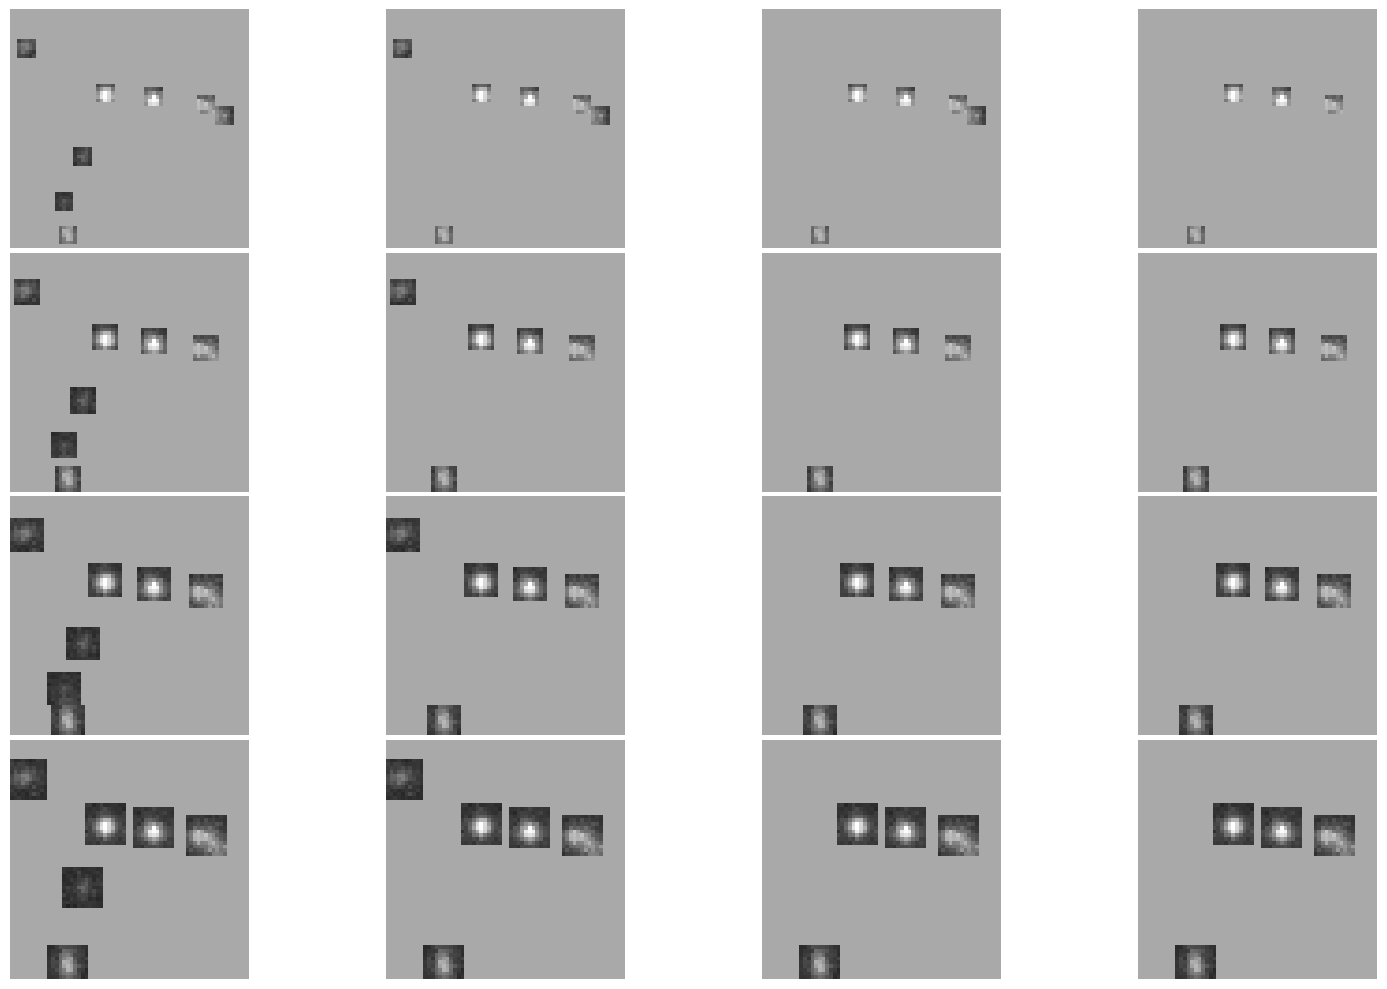

In [82]:

main_folder_path = "/Users/laurabreimann/Library/CloudStorage/Dropbox-HMS/data_compression_localizations/figure_4_data/astigmatism"
# Load and plot
load_and_plot_npz_files(main_folder_path)

# DNA PAINT

In [ ]:

main_folder = '/Users/laurabreimann/Desktop/DNA-PAINT'
original_file = '/Users/laurabreimann/Desktop/DNA-PAINT_raw/RawFramesforTraining_P5-IS_20pM.tif'


In [ ]:
# Original file size
original_file_size = 2644997930    # in bytes


# Color map for kernel sizes
k_colors = plt.cm.viridis(np.linspace(0, 1, 4))
lev_shades = np.linspace(0.5, 1, 4)
k_values = [11,15,19,23]

# Marker map for threshold values
threshold_markers = {15: 'o', 25: '^', 45: 's', 65: 'd'}

# Iterate through each subfolder and calculate median SSIM score and file size
results = {}
for folder in sorted(os.listdir(main_folder), key=natural_sort_key):
    if os.path.isdir(os.path.join(main_folder, folder)):
        uncompressed_folder = os.path.join(main_folder, folder, 'uncompressed')
        # Handling different file endings by searching for the common beginning
        for file_name in os.listdir(uncompressed_folder):
            if file_name.startswith('PAINT'):
                compressed_file = os.path.join(uncompressed_folder, file_name)
                break
        median_ssim = calculate_ssim(original_file, compressed_file)
        total_file_size = get_total_size_of_files(os.path.join(main_folder, folder), ['.mp4', '.sparz'])  
        file_size_percentage = (total_file_size / original_file_size) * 100
        k_value, lev_value = extract_k_lev(folder)
        threshold = int(re.search(r'rt(\d+)', folder).group(1))  # Extract threshold value

        # Choose marker based on threshold value
        marker = threshold_markers[threshold]

        color = k_colors[k_values.index(k_value)]

        # Choose shade based on lev value
        shade = lev_shades[lev_value] if lev_value is not None else 0.5

        if lev_value not in results:
            results[lev_value] = []
        results[lev_value].append({'median_ssim': median_ssim, 'file_size_percentage': file_size_percentage, 'color': color, 'shade': shade, 'marker': marker })

In [ ]:
#show results table
df = pd.DataFrame(results)  
save_path = '/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/Results_DNA-PAINT_240603.csv'
df.to_csv(save_path)
print(df)

In [ ]:
# Create facet plot
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for i, (level, data_list) in enumerate(sorted(results.items())):
    ax = axs[i]
    ax.set_xlabel('Percentage of Original File Size')
    ax.set_title(f'Compression Level {level}')
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.2, zorder=0)
    for data in data_list:
        ax.scatter(data['file_size_percentage'], data['median_ssim'], color=data['color'],s=250, marker=data['marker'], alpha=0.9)
    ax.set_xlim(0, 15)

# Remove lines on top and right
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Set common Y axis label
fig.text(0, 0.55, 'Median SSIM Score', va='center', rotation='vertical')

plt.tight_layout()
#plt.show()

# Save the plot as a PDF
output_file = '/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/Figure_3_SSIM_filesize_DNA-PAINT_240603.pdf'
plt.tight_layout()
plt.savefig(output_file, format='pdf')
plt.close()

## Overview images from grid search

In [61]:
# Define the parameters used in grid search
kernel_sizes = [11,15,19,23]  
rel_thresholds = [0.15, 0.25, 0.45, 0.65]  
compression_levels = [0, 1, 2, 3]  


In [76]:
# Reconstruction of the full array from the sparse data
def reconstruct_array(data):
    shape = tuple(data['shape'])
    fill_value = data['fill_value']
    coords = data['coords']
    sparse_data = data['data']

    full_array = np.full(shape, fill_value)
    for i, coord in enumerate(zip(*coords)):
        full_array[coord] = sparse_data[i]
    return full_array


# Load and plot the npz files
def load_and_plot_npz_files(folder_path, compression_level=0):
    fig, axs = plt.subplots(len(kernel_sizes), len(rel_thresholds), figsize=(15, 10))

    for root, dirs, files in os.walk(folder_path):
        for dir in dirs:
            kernel_size, rel_threshold, comp_level = extract_parameters(dir)

            if comp_level == compression_level:
                if kernel_size in kernel_sizes and rel_threshold in rel_thresholds:
                    file_paths = ['RawFramesforTraining_P5-IS_20pM.npz'] 
                    for index, file_name in enumerate(file_paths):
                        file_path = os.path.join(root, dir, file_name)
                        if os.path.exists(file_path):
                            data = np.load(file_path)
                            full_array = reconstruct_array(data)
                            selected_image = full_array[25]

                            # Find the correct subplot
                            i = kernel_sizes.index(kernel_size)
                            j = rel_thresholds.index(rel_threshold) #+ index

                            # Set color for values below the colormap range
                            cmap = plt.cm.gray
                            cmap.set_under('darkgray')

                            # Plot the selected image
                            axs[i, j].imshow(selected_image, cmap=cmap, interpolation='none', norm=mcolors.Normalize(vmin=0.1, vmax=np.max(selected_image)))
                            axs[i, j].axis('off')

                            # Set title for the first image of the pair
                            # if index == 0:
                            #     axs[i, j].set_title(f'k{kernel_size} thr{rel_threshold}')
   

    plt.tight_layout()

      # Save the plot as a PDF
    plt.savefig('/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/npz_profiles_figure4_PAINT.pdf', format='pdf')  

    plt.show()

# Extract the parameters from the folder name after the grid search
def extract_parameters(folder_name):
    match = re.search(r'k(\d+)_rt(\d+)_lev(\d+)', folder_name)
    if match:
        kernel_size = int(match.group(1))
        rel_threshold = float(f"0.{match.group(2)}")
        compression_level = int(match.group(3))
        return kernel_size, rel_threshold, compression_level
    else:
        return None, None, None

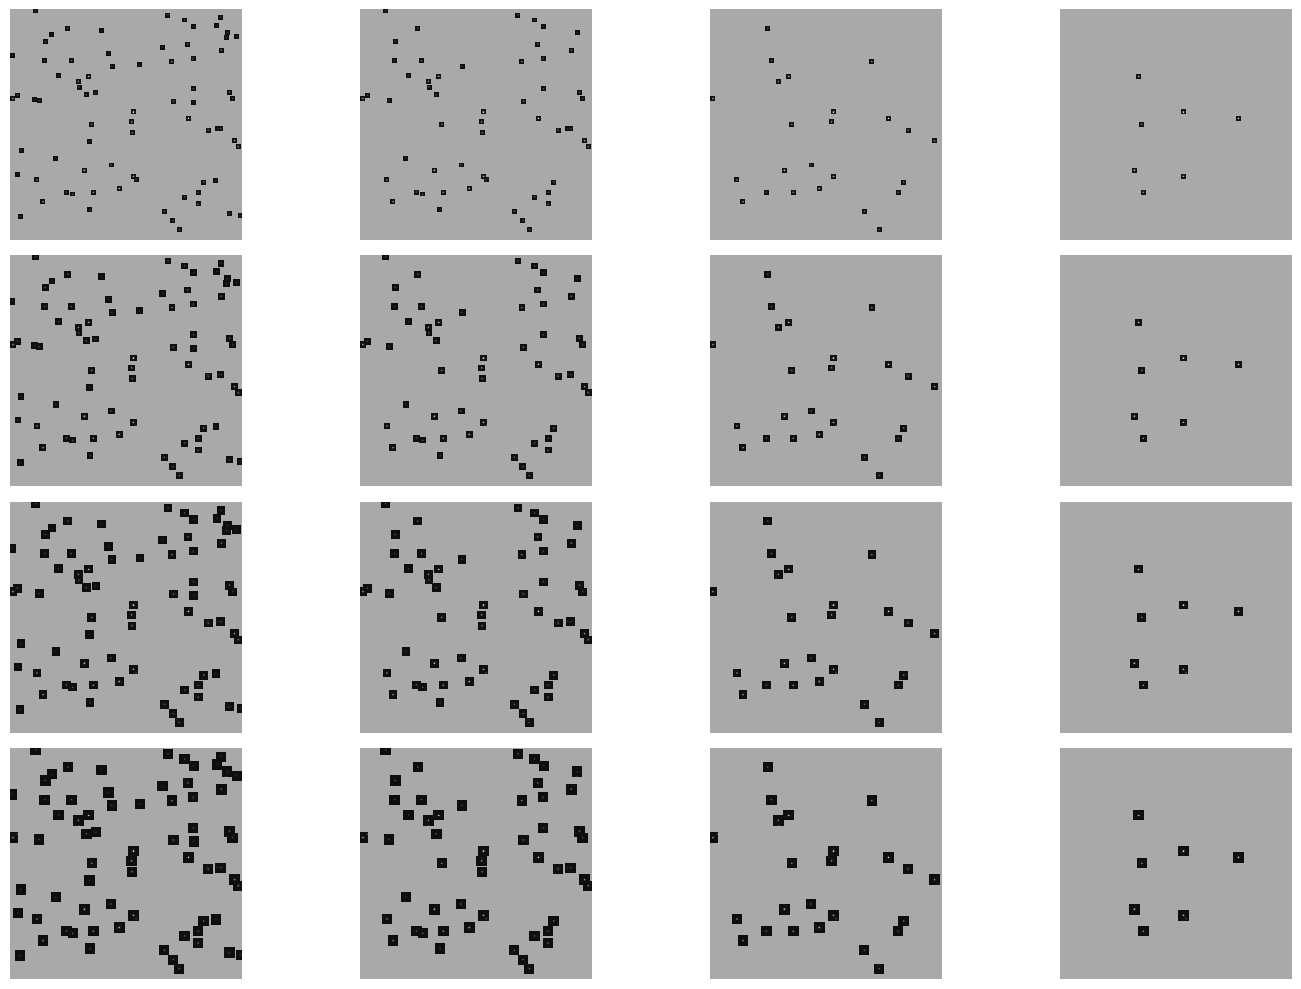

In [77]:

main_folder_path = "/Users/laurabreimann/Library/CloudStorage/Dropbox-HMS/data_compression_localizations/figure_4_data/DNA-PAINT"
# Load and plot
load_and_plot_npz_files(main_folder_path)